In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
import joblib

# Fix path — go up one level from notebooks/ to project root
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Base directory: {BASE_DIR}")

train = pd.read_csv(os.path.join(BASE_DIR, "data", "processed", "train_classical.csv"))
val = pd.read_csv(os.path.join(BASE_DIR, "data", "processed", "val_classical.csv"))
test = pd.read_csv(os.path.join(BASE_DIR, "data", "processed", "test_classical.csv"))

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Base directory: c:\Users\HP\Desktop\customer-support-nlp-agent
Train: 18810, Val: 4031, Test: 4031


In [3]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train = vectorizer.fit_transform(train['text_clean'])
X_val = vectorizer.transform(val['text_clean'])
X_test = vectorizer.transform(test['text_clean'])

y_train = train['label']
y_val = val['label']
y_test = test['label']

print(f"Feature matrix shape: {X_train.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Feature matrix shape: (18810, 3858)
Vocabulary size: 3858


In [4]:
results = {}

# Logistic Regression
print("="*50)
print("Training: Logistic Regression")
print("="*50)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_val)
lr_acc = accuracy_score(y_val, lr_preds)
print(f"Validation Accuracy: {lr_acc:.4f}")
print(classification_report(y_val, lr_preds))
results['Logistic Regression'] = lr_acc

# SVM
print("="*50)
print("Training: Linear SVM")
print("="*50)
svm = LinearSVC(class_weight='balanced', max_iter=2000, C=1.0)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_val)
svm_acc = accuracy_score(y_val, svm_preds)
print(f"Validation Accuracy: {svm_acc:.4f}")
print(classification_report(y_val, svm_preds))
results['Linear SVM'] = svm_acc

# Naive Bayes
print("="*50)
print("Training: Naive Bayes")
print("="*50)
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train, y_train)
nb_preds = nb.predict(X_val)
nb_acc = accuracy_score(y_val, nb_preds)
print(f"Validation Accuracy: {nb_acc:.4f}")
print(classification_report(y_val, nb_preds))
results['Naive Bayes'] = nb_acc

Training: Logistic Regression
Validation Accuracy: 0.9873
                          precision    recall  f1-score   support

            cancel_order       0.98      0.98      0.98       150
            change_order       0.95      0.95      0.95       149
 change_shipping_address       0.98      0.99      0.98       146
  check_cancellation_fee       1.00      1.00      1.00       143
           check_invoice       0.99      0.97      0.98       150
   check_payment_methods       1.00      1.00      1.00       150
     check_refund_policy       0.99      1.00      1.00       149
               complaint       1.00      1.00      1.00       150
contact_customer_service       1.00      0.99      0.99       150
     contact_human_agent       0.99      0.99      0.99       150
          create_account       0.98      0.99      0.98       149
          delete_account       0.96      1.00      0.98       150
        delivery_options       0.93      1.00      0.96       149
         delivery

In [5]:
print("\n===== MODEL COMPARISON =====")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:25s}: {acc:.4f} ({acc*100:.2f}%)")

best_model_name = max(results, key=results.get)
print(f"\nBest baseline model: {best_model_name}")


===== MODEL COMPARISON =====
Linear SVM               : 0.9893 (98.93%)
Naive Bayes              : 0.9883 (98.83%)
Logistic Regression      : 0.9873 (98.73%)

Best baseline model: Linear SVM


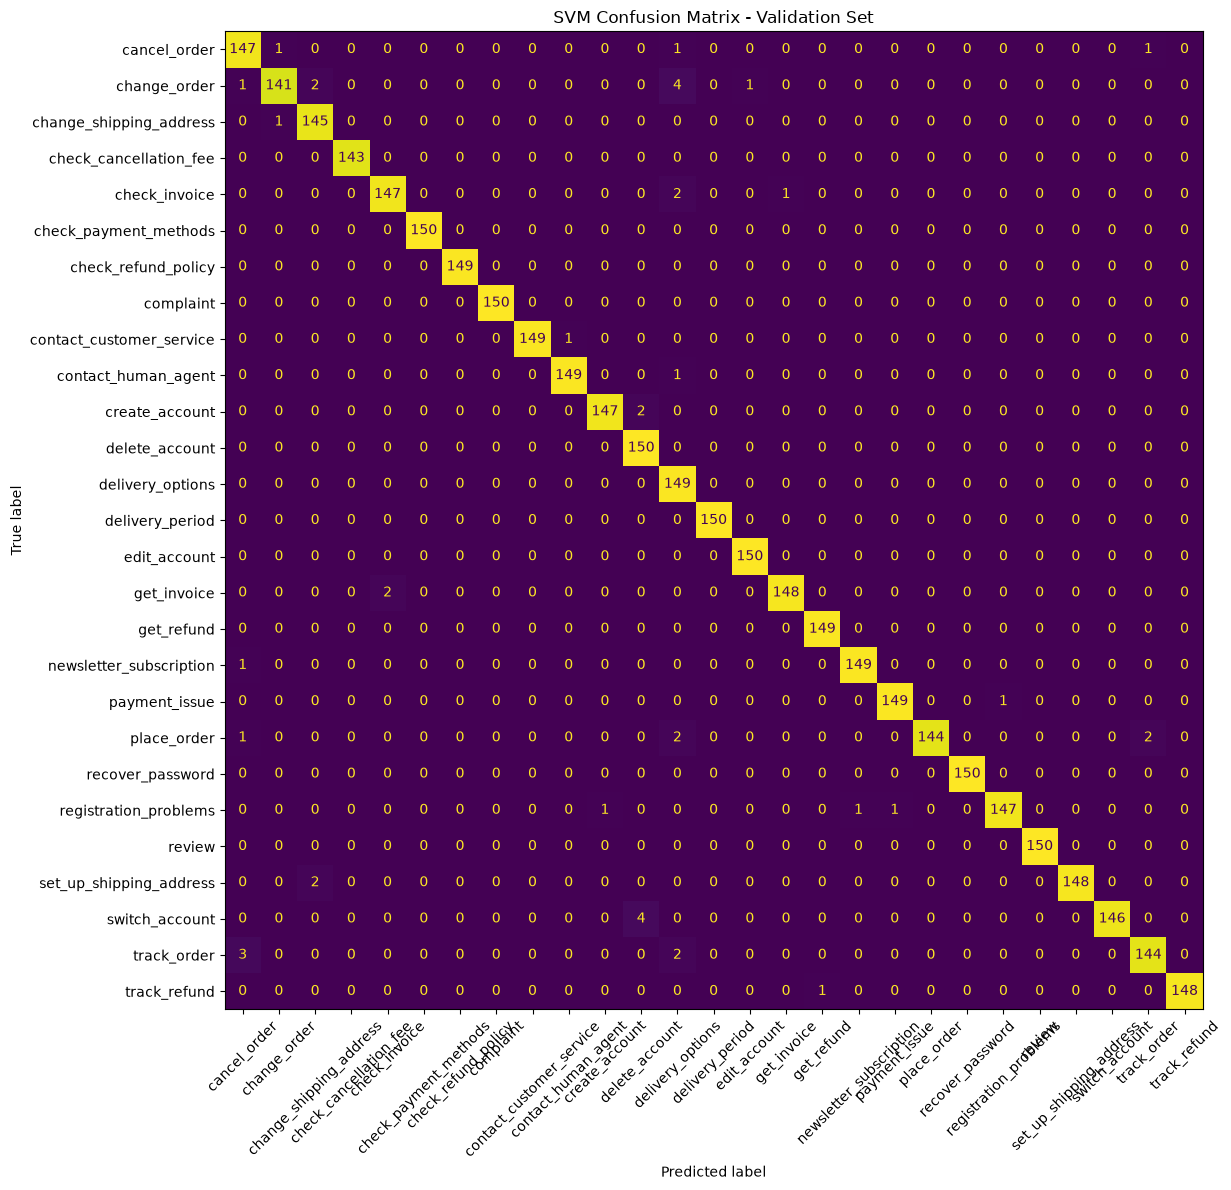

In [6]:
cm = confusion_matrix(y_val, svm_preds, labels=svm.classes_)
fig, ax = plt.subplots(figsize=(16, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("SVM Confusion Matrix - Validation Set")
plt.tight_layout()
plt.show()

In [7]:
models_dir = os.path.join(BASE_DIR, "models")
os.makedirs(models_dir, exist_ok=True)

joblib.dump(svm, os.path.join(models_dir, "svm_tfidf.pkl"))
joblib.dump(vectorizer, os.path.join(models_dir, "tfidf_vectorizer.pkl"))
print("Models saved successfully")

Models saved successfully
